# Armenian Glitch Token Hunt

Tokenizers are the layer everyone skips. This notebook digs through eight of them
and asks one question: **what does the world's tokenizer infrastructure actually
know about Armenian?**

What we hunt for:

1. **Vocab census** - how many Armenian tokens each tokenizer has, and the longest ones.
2. **Merge archaeology** - which Armenian strings a BPE tokenizer learned *first*.
3. **Corpus efficiency** - how many tokens each tokenizer spends on the same
   Armenian Wikipedia text (and the "Armenian premium" vs English).
4. **Token explosion** - words that cost *more tokens than they have letters*.
5. **Glitch candidates** - vocab entries that exist but were (almost) never trained,
   in the spirit of GPT-2's famous ` SolidGoldMagikarp` (Rumbelow & Watkins,
   LessWrong 2023): tokens that sat in the vocabulary while the model never really
   saw them, so the embedding never learned anything.

Deep dive: **XLM-R** (it actually tried to cover Armenian). Every analysis runs on
all eight tokenizers through one tiny registry (`tokenizer_registry.py`), so
swapping in a new tokenizer is a one-line change.

All results are saved as JSON under `out/` - the notebook is the experiment,
`build_report.py` compiles the JSONs into an HTML report.

In [1]:
import os

# quiet the hub before anything imports it
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

import json
import re
import sys
import time
import unicodedata
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from tokenizer_registry import ARMENIAN_RE, TOKENIZERS, load_all

SEED = 509
OUT = Path("out"); OUT.mkdir(exist_ok=True)
DATA = Path("data"); DATA.mkdir(exist_ok=True)

# knobs (env-overridable so a smoke run and the real run share one notebook)
MAX_CHARS_HY = int(os.environ.get("ATH_MAX_CHARS", 20_000_000))
MAX_CHARS_EN = int(os.environ.get("ATH_EN_MAX_CHARS", 5_000_000))
SKIP_WEIGHTS = os.environ.get("ATH_SKIP_WEIGHTS", "0") == "1"

def save_json(name: str, obj) -> None:
    p = OUT / name
    p.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"saved {p} ({p.stat().st_size:,} bytes)")

print(f"corpus target: hy={MAX_CHARS_HY:,} chars, en={MAX_CHARS_EN:,} chars, "
      f"skip_weights={SKIP_WEIGHTS}")

corpus target: hy=20,000,000 chars, en=5,000,000 chars, skip_weights=False


## 1. Load the tokenizers

Three algorithm families in the lineup:

- **SentencePiece on raw text** (XLM-R, Gemma 2): tokens are unicode strings, the
  low-line `▁` marks a word start. Unknown characters can fall to `<unk>` or byte pieces.
- **WordPiece** (mBERT): greedy longest-match, `##` marks word-continuation.
- **Byte-level BPE** (GPT-2, cl100k, o200k, Llama 3, Qwen 2.5): text becomes UTF-8
  bytes first, merges are learned over bytes. Nothing is ever `<unk>` - but an
  Armenian letter is 2 bytes, so an unmerged letter costs 2 tokens.

In [2]:
toks = load_all()
DEMO = "Բարև ձեզ, Երևան։ Tokenizers are fun."
for name, t in toks.items():
    ids = t.encode(DEMO)
    print(f"{t.label:42s} {len(ids):>2d} tokens  {t.token_pieces(ids)}")

C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XLM-R (SentencePiece, 250k, 2019)          13 tokens  ['Բար', 'եւ', 'ձեզ', ',', 'Երեւան', '։', 'To', 'ken', 'izer', 's', 'are', 'fun', '.']
mBERT (WordPiece, 120k, 2018)              16 tokens  ['Բ', '##ար', '##և', 'ձ', '##ե', '##զ', ',', 'Երևան', '։', 'To', '##ken', '##izer', '##s', 'are', 'fun', '.']
GPT-2 (byte BPE, 50k, 2019)                34 tokens  ['�', '�', '�', '�', '�', '�', '�', '�', ' ', '�', '�', '�', '�', '�', '�', ',', ' ', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', ' Token', 'izers', ' are', ' fun', '.']
cl100k / GPT-4 (byte BPE, 100k, 2023)      34 tokens  ['�', '�', '�', '�', '�', '�', '�', '�', ' ', '�', '�', '�', '�', '�', '�', ',', ' ', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', ' Token', 'izers', ' are', ' fun', '.']
o200k / GPT-4o (byte BPE, 200k, 2024)      13 tokens  ['Բ', 'ար', 'և', ' ձեզ', ',', ' Երև', 'ան', '։', ' Token', 'izers', ' are', ' fun', '.']
Llama 3 (byte BPE, 128k, 2024)             31 tokens  ['�', '�', 'ա', '�'

## 2. Vocab census - who even knows Armenian exists?

For every tokenizer: decode the *entire* vocabulary and count tokens that contain
at least one Armenian character (U+0530-U+058F plus the five ligatures ﬓﬔﬕﬖﬗ).

In [3]:
def census_one(t):
    surfaces = t.all_token_strings()
    arm = {i: s for i, s in surfaces.items() if ARMENIAN_RE.search(s)}
    pure = {i: s for i, s in arm.items()
            if re.fullmatch(r"[԰-֏ﬓ-ﬗ]+", s.strip())}
    by_len = sorted(arm.items(), key=lambda kv: len(kv[1].strip()), reverse=True)
    longest = [{"id": i, "surface": s.strip(),
                "internal": t.internal_forms([i])[0],
                "n_chars": len(s.strip())} for i, s in by_len[:10]]
    return {
        "label": t.label,
        "vocab_size": t.vocab_size,
        "n_armenian": len(arm),
        "pct_armenian": round(100 * len(arm) / t.vocab_size, 3),
        "n_pure_armenian": len(pure),
        "longest": longest,
    }, arm

census, armenian_ids = {}, {}
for name, t in toks.items():
    t0 = time.perf_counter()
    census[name], armenian_ids[name] = census_one(t)
    c = census[name]
    print(f"{c['label']:42s} vocab={c['vocab_size']:>7,d}  "
          f"armenian={c['n_armenian']:>6,d} ({c['pct_armenian']:5.2f}%)  "
          f"longest='{c['longest'][0]['surface'] if c['longest'] else '-'}'  "
          f"[{time.perf_counter()-t0:.1f}s]")
save_json("vocab_census.json", census)

XLM-R (SentencePiece, 250k, 2019)          vocab=250,002  armenian= 3,528 ( 1.41%)  longest='քաղաքականություն'  [6.5s]


mBERT (WordPiece, 120k, 2018)              vocab=119,547  armenian= 1,236 ( 1.03%)  longest='ուսումնասիրությունների'  [2.7s]
GPT-2 (byte BPE, 50k, 2019)                vocab= 50,257  armenian=     0 ( 0.00%)  longest='-'  [0.1s]


cl100k / GPT-4 (byte BPE, 100k, 2023)      vocab=100,277  armenian=     0 ( 0.00%)  longest='-'  [0.2s]


o200k / GPT-4o (byte BPE, 200k, 2024)      vocab=200,019  armenian= 1,753 ( 0.88%)  longest='հնարավորություն'  [0.4s]


Llama 3 (byte BPE, 128k, 2024)             vocab=128,256  armenian=     2 ( 0.00%)  longest='ա�'  [3.4s]


Gemma 2 (SentencePiece, 256k, 2024)        vocab=256,000  armenian=   246 ( 0.10%)  longest='ագրություններ'  [8.0s]


Qwen 2.5 (byte BPE, 152k, 2024)            vocab=151,665  armenian=    79 ( 0.05%)  longest='ա'  [4.1s]
saved out\vocab_census.json (10,749 bytes)


The longest Armenian tokens are where tokenizers confess what they memorized -
a 250k-vocab model has room to store whole words like `շնորհակալություն`.

In [4]:
for name in toks:
    print(f"\n=== {census[name]['label']}")
    for e in census[name]["longest"][:5]:
        print(f"  {e['n_chars']:>2d} chars  id={e['id']:>7d}  {e['internal']!r}")


=== XLM-R (SentencePiece, 250k, 2019)
  16 chars  id= 143904  'քաղաքականություն'
  16 chars  id= 180896  'ծառայությունների'
  16 chars  id= 191566  'գործունեությունը'
  16 chars  id= 193908  'ընտրություններին'
  16 chars  id= 208176  'իշխանությունների'

=== mBERT (WordPiece, 120k, 2018)
  22 chars  id=  78300  'ուսումնասիրությունների'
  17 chars  id= 100014  'Ուսումնասիրութեան'
  16 chars  id=  58370  'համառուսաստանյան'
  16 chars  id=  67202  'հրատարակչություն'
  16 chars  id=  99922  'Արեւմտահայաստանի'

=== GPT-2 (byte BPE, 50k, 2019)

=== cl100k / GPT-4 (byte BPE, 100k, 2023)

=== o200k / GPT-4o (byte BPE, 200k, 2024)
  15 chars  id= 158862  ' \\xd5\\xb0\\xd5\\xb6\\xd5\\xa1\\xd6\\x80\\xd5\\xa1\\xd5\\xbe\\xd5\\xb8\\xd6\\x80\\xd5\\xb8\\xd6\\x82\\xd5\\xa9\\xd5\\xb5\\xd5\\xb8\\xd6\\x82\\xd5\\xb6'
  14 chars  id= 160638  ' \\xd5\\x80\\xd5\\xa1\\xd5\\xb6\\xd6\\x80\\xd5\\xa1\\xd5\\xba\\xd5\\xa5\\xd5\\xbf\\xd5\\xb8\\xd6\\x82\\xd5\\xa9\\xd5\\xb5\\xd5\\xa1\\xd5\\xb6'
  13 chars  id= 134325  

## 3. Merge archaeology - what got learned first?

A BPE vocabulary is built greedily: the most frequent pair is merged first. The
merge list is therefore a *fossil record* - the rank of the first Armenian merge
tells you how far down the training corpus's priority list Armenian sat.

- tiktoken exposes ranks directly (`_mergeable_ranks`).
- HF byte-BPE tokenizers store an ordered merge list in `tokenizer.json`
  (written in the GPT-2 byte alphabet, which we have to invert).
- XLM-R has **no merges** - SentencePiece stores a per-piece *score* instead.
  The filename says `sentencepiece.bpe.model`; the scores will tell us what it
  really is (BPE scores are integer ranks, unigram scores are float log-probs).

In [5]:
def gpt2_byte_decoder() -> dict[str, int]:
    """Inverse of GPT-2's bytes_to_unicode: printable-alias char -> original byte."""
    bs = list(range(33, 127)) + list(range(161, 173)) + list(range(174, 256))
    cs = bs[:]
    n = 0
    for b in range(256):
        if b not in bs:
            bs.append(b); cs.append(256 + n); n += 1
    return {chr(c): b for b, c in zip(bs, cs)}

BYTE_DEC = gpt2_byte_decoder()

def merged_surface(a: str, b: str) -> str:
    """The string a merge produces. CRITICAL: for byte-level alphabets the two
    halves of a multi-byte char are individually invalid UTF-8, so we must
    concatenate the BYTES of both parts first and decode once - decoding each
    part alone silently drops every split character (that bug hid Qwen's
    Armenian merges entirely on the first attempt)."""
    if all(ch in BYTE_DEC for ch in a + b):  # byte-level alphabet
        raw = bytes(BYTE_DEC[ch] for ch in a + b)
        return raw.decode("utf-8", errors="ignore")
    return (a + b).replace("▁", " ")         # sentencepiece-style literal pieces

def first_armenian_merges(merges: list, top=10):
    hits = []
    for rank, m in enumerate(merges):
        a, b = m if isinstance(m, (list, tuple)) else m.split(" ", 1)
        s = merged_surface(a, b)
        if ARMENIAN_RE.search(s):
            hits.append({"rank": rank, "pct_through": round(100 * rank / len(merges), 1),
                         "pair": [a, b], "result": s})
            if len(hits) >= top:
                break
    return hits, len(merges)

In [6]:
from huggingface_hub import hf_hub_download

merge_report = {}

# tiktoken family: ranks ARE the merge order (ranks 0-255 are raw bytes)
import tiktoken
for name in ["gpt2", "cl100k", "o200k"]:
    enc = toks[name].raw
    ranked = sorted(enc._mergeable_ranks.items(), key=lambda kv: kv[1])
    hits = []
    for bts, rank in ranked:
        s = bts.decode("utf-8", errors="ignore")
        if ARMENIAN_RE.search(s):
            hits.append({"rank": rank, "pct_through": round(100 * rank / len(ranked), 1),
                         "result": s})
            if len(hits) >= 10:
                break
    merge_report[name] = {"kind": "tiktoken ranks", "n_merges": len(ranked),
                          "first_armenian": hits}
    first = hits[0] if hits else None
    print(f"{toks[name].label:42s} first Armenian at rank "
          f"{first['rank'] if first else '-'} "
          f"({first['pct_through'] if first else '-'}% through) -> "
          f"{first['result'] if first else 'NONE'}")

# HF byte-BPE / SentencePiece-BPE: ordered merges in tokenizer.json
for name in ["llama3", "qwen2.5", "gemma2"]:
    tj = json.loads(Path(hf_hub_download(TOKENIZERS[name]["repo"], "tokenizer.json"))
                    .read_text(encoding="utf-8"))
    merges = tj["model"].get("merges", [])
    hits, n = first_armenian_merges(merges)
    merge_report[name] = {"kind": "tokenizer.json merges", "n_merges": n,
                          "first_armenian": hits}
    first = hits[0] if hits else None
    print(f"{toks[name].label:42s} first Armenian at rank "
          f"{first['rank'] if first else '-'} "
          f"({first['pct_through'] if first else '-'}% through) -> "
          f"{first['result'] if first else 'NONE'}")

GPT-2 (byte BPE, 50k, 2019)                first Armenian at rank - (-% through) -> NONE


cl100k / GPT-4 (byte BPE, 100k, 2023)      first Armenian at rank - (-% through) -> NONE


o200k / GPT-4o (byte BPE, 200k, 2024)      first Armenian at rank 619 (0.3% through) -> ա


Llama 3 (byte BPE, 128k, 2024)             first Armenian at rank 263556 (94.1% through) -> ա


Qwen 2.5 (byte BPE, 152k, 2024)            first Armenian at rank 144669 (95.6% through) -> ա


Gemma 2 (SentencePiece, 256k, 2024)        first Armenian at rank 40020 (6.9% through) -> ու


### XLM-R's analog: SentencePiece piece scores

In [7]:
import sentencepiece as spm

sp_path = hf_hub_download("FacebookAI/xlm-roberta-base", "sentencepiece.bpe.model")
sp = spm.SentencePieceProcessor(model_file=sp_path)
print("pieces:", sp.get_piece_size())
print("sample scores:", [(sp.id_to_piece(i), round(sp.get_score(i), 3))
                         for i in range(5, 10)])

arm_pieces = [(sp.id_to_piece(i), sp.get_score(i), i)
              for i in range(sp.get_piece_size())
              if ARMENIAN_RE.search(sp.id_to_piece(i))]
arm_pieces.sort(key=lambda x: -x[1])
print(f"\nArmenian pieces in the SP model: {len(arm_pieces):,}")
print("top-15 by score (the pieces SentencePiece is most confident about):")
for piece, score, i in arm_pieces[:15]:
    print(f"  {score:>9.3f}  {piece}")

merge_report["xlm-roberta"] = {
    "kind": "sentencepiece scores",
    "n_pieces": sp.get_piece_size(),
    "n_armenian_pieces": len(arm_pieces),
    "top_armenian": [{"piece": p, "score": round(s, 4)} for p, s, _ in arm_pieces[:20]],
    "bottom_armenian": [{"piece": p, "score": round(s, 4)} for p, s, _ in arm_pieces[-10:]],
}

# mBERT: WordPiece has no merges either; the first Armenian vocab index is the fossil
mb_first = min(armenian_ids["mbert"])
merge_report["mbert"] = {"kind": "vocab order", "first_armenian_index": mb_first,
                         "first_armenian_token": toks["mbert"].internal_forms([mb_first])[0]}
print(f"\nmBERT: first Armenian vocab entry at index {mb_first}: "
      f"{merge_report['mbert']['first_armenian_token']!r}")

save_json("merge_order.json", merge_report)

pieces: 250000
sample scores: [('▁', -3.93), ('s', -5.073), ('▁de', -5.307), ('-', -5.404), ('▁a', -5.53)]



Armenian pieces in the SP model: 3,528
top-15 by score (the pieces SentencePiece is most confident about):
     -8.504  ▁է
     -8.618  ի
     -8.729  ը
     -9.109  ն
     -9.190  ում
     -9.229  ▁եւ
     -9.656  ▁են
     -9.676  ին
     -9.726  ել
     -9.809  ։
     -9.852  ▁որ
     -9.864  ական
     -9.900  ների
     -9.968  ով
    -10.046  ության

mBERT: first Armenian vocab entry at index 625: 'Ա'
saved out\merge_order.json (7,746 bytes)


## 4. Corpus efficiency - the price of writing in Armenian

Same text, eight tokenizers: how many tokens does 20M characters of Armenian
Wikipedia cost? And how does that compare to English Wikipedia through the same
tokenizer? The ratio is the **Armenian premium**: how many times more tokens per
character you pay for Armenian. For an API biller or a context window, this *is*
the exchange rate.

In [8]:
import datasets
datasets.disable_progress_bars()

SEP = "\n\n=====ARTICLE_BREAK=====\n\n"

def wiki_sample(lang: str, max_chars: int) -> list[str]:
    cache = DATA / f"{lang}_wiki_{max_chars}.txt"
    if cache.exists():
        arts = cache.read_text(encoding="utf-8").split(SEP)
        print(f"[{lang}] cache hit: {len(arts)} articles, "
              f"{sum(len(a) for a in arts):,} chars")
        return arts
    print(f"[{lang}] streaming wikimedia/wikipedia 20231101.{lang} ...")
    stream = datasets.load_dataset("wikimedia/wikipedia", f"20231101.{lang}",
                                   split="train", streaming=True)
    arts, total = [], 0
    for ex in stream:
        arts.append(ex["text"])
        total += len(ex["text"])
        if total >= max_chars:
            break
    cache.write_text(SEP.join(arts), encoding="utf-8")
    print(f"[{lang}] fetched {len(arts)} articles, {total:,} chars")
    return arts

hy_articles = wiki_sample("hy", MAX_CHARS_HY)
en_articles = wiki_sample("en", MAX_CHARS_EN)

[hy] cache hit: 3149 articles, 20,037,131 chars
[en] cache hit: 152 articles, 5,007,358 chars


In [9]:
def corpus_stats(t, articles, count_ids=False):
    n_tokens, counter = 0, Counter() if count_ids else None
    t0 = time.perf_counter()
    B = 200
    for k in range(0, len(articles), B):
        batch = articles[k:k + B]
        if t.kind == "hf":
            for ids in t.raw(batch, add_special_tokens=False)["input_ids"]:
                n_tokens += len(ids)
                if count_ids:
                    counter.update(ids)
        else:
            for ids in t.raw.encode_batch(batch, disallowed_special=()):
                n_tokens += len(ids)
                if count_ids:
                    counter.update(ids)
    dt = time.perf_counter() - t0
    chars = sum(len(a) for a in articles)
    bts = sum(len(a.encode("utf-8")) for a in articles)
    return {"n_tokens": n_tokens, "n_chars": chars, "n_bytes": bts,
            "chars_per_token": round(chars / n_tokens, 3),
            "bytes_per_token": round(bts / n_tokens, 3),
            "seconds": round(dt, 1)}, counter

efficiency, hy_counters = {}, {}
for name, t in toks.items():
    # token-id counts are only consumed by the XLM-R glitch hunt; counting for
    # all 8 tokenizers costs hundreds of MB on this 16 GB machine for nothing
    hy, hy_counters[name] = corpus_stats(t, hy_articles,
                                         count_ids=(name == "xlm-roberta"))
    en, _ = corpus_stats(t, en_articles)
    premium = (hy["n_tokens"] / hy["n_chars"]) / (en["n_tokens"] / en["n_chars"])
    efficiency[name] = {"label": t.label, "hy": hy, "en": en,
                        "armenian_premium": round(premium, 2)}
    print(f"{t.label:42s} hy: {hy['chars_per_token']:>5.2f} chars/tok  "
          f"en: {en['chars_per_token']:>5.2f} chars/tok  premium x{premium:.2f}")
    save_json("corpus_efficiency.json", efficiency)   # checkpoint per tokenizer

XLM-R (SentencePiece, 250k, 2019)          hy:  3.33 chars/tok  en:  4.18 chars/tok  premium x1.26
saved out\corpus_efficiency.json (494 bytes)


mBERT (WordPiece, 120k, 2018)              hy:  2.49 chars/tok  en:  4.49 chars/tok  premium x1.80
saved out\corpus_efficiency.json (975 bytes)


GPT-2 (byte BPE, 50k, 2019)                hy:  0.57 chars/tok  en:  4.57 chars/tok  premium x8.05
saved out\corpus_efficiency.json (1,453 bytes)


cl100k / GPT-4 (byte BPE, 100k, 2023)      hy:  0.57 chars/tok  en:  4.62 chars/tok  premium x8.14
saved out\corpus_efficiency.json (1,944 bytes)


o200k / GPT-4o (byte BPE, 200k, 2024)      hy:  2.84 chars/tok  en:  4.68 chars/tok  premium x1.65
saved out\corpus_efficiency.json (2,433 bytes)


Llama 3 (byte BPE, 128k, 2024)             hy:  0.65 chars/tok  en:  4.63 chars/tok  premium x7.11
saved out\corpus_efficiency.json (2,918 bytes)


Gemma 2 (SentencePiece, 256k, 2024)        hy:  1.79 chars/tok  en:  4.60 chars/tok  premium x2.57
saved out\corpus_efficiency.json (3,406 bytes)


Qwen 2.5 (byte BPE, 152k, 2024)            hy:  1.03 chars/tok  en:  4.49 chars/tok  premium x4.37
saved out\corpus_efficiency.json (3,893 bytes)


One bar chart, one number per tokenizer: characters of Armenian you get for one
token. Higher = cheaper.

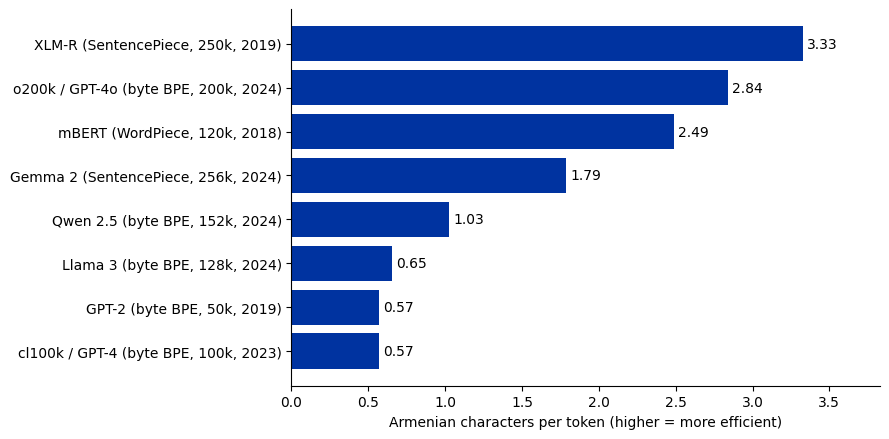

In [10]:
import matplotlib.pyplot as plt

ARM_RED, ARM_BLUE, ARM_ORANGE = "#D90012", "#0033A0", "#F2A800"

order = sorted(efficiency, key=lambda n: -efficiency[n]["hy"]["chars_per_token"])
fig, ax = plt.subplots(figsize=(9, 4.5))
vals = [efficiency[n]["hy"]["chars_per_token"] for n in order]
bars = ax.barh([efficiency[n]["label"] for n in order], vals, color=ARM_BLUE)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.invert_yaxis()
ax.set_xlabel("Armenian characters per token (higher = more efficient)")
ax.set_xlim(0, max(vals) * 1.15)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "fig_efficiency.png", dpi=150)
plt.show()

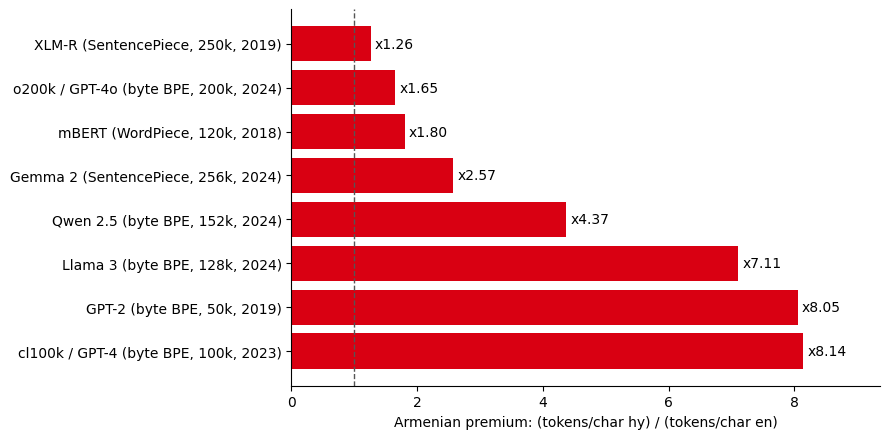

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
prem = [efficiency[n]["armenian_premium"] for n in order]
bars = ax.barh([efficiency[n]["label"] for n in order], prem, color=ARM_RED)
ax.bar_label(bars, fmt="x%.2f", padding=3)
ax.invert_yaxis()
ax.axvline(1.0, color="#555", lw=1, ls="--")
ax.set_xlabel("Armenian premium: (tokens/char hy) / (tokens/char en)")
ax.set_xlim(0, max(prem) * 1.15)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "fig_premium.png", dpi=150)
plt.show()

## 5. Token explosion - words that cost more tokens than letters

In a byte-level BPE, an Armenian letter is 2 UTF-8 bytes. If the tokenizer never
learned merges for it, a k-letter word can cost up to **2k tokens**. We scan every
distinct Armenian word in the corpus and look for ratio > 1 offenders.
(Words are encoded bare, without a leading space - the worst case.)

In [12]:
WORD_RE = re.compile(r"[Ա-Ֆա-և]+")

word_freq = Counter()
for a in hy_articles:
    word_freq.update(WORD_RE.findall(a))
words = [w for w, _ in word_freq.most_common(250_000)]
print(f"{len(word_freq):,} distinct Armenian words; analyzing top {len(words):,}")
del word_freq

explosion = {}
for name, t in toks.items():
    # unk words: byte-level BPE can never produce <unk>, but SentencePiece
    # without byte fallback and WordPiece can - those words are INVISIBLE to
    # the model, which is worse than exploding
    unk_id = t.raw.unk_token_id if t.kind == "hf" else None
    lens, n_unk_words = [], 0
    B = 20_000
    for k in range(0, len(words), B):
        batch = words[k:k + B]
        if t.kind == "hf":
            batch_ids = t.raw(batch, add_special_tokens=False)["input_ids"]
        else:
            batch_ids = t.raw.encode_batch(batch, disallowed_special=())
        lens += [len(ids) for ids in batch_ids]
        if unk_id is not None:
            n_unk_words += sum(1 for ids in batch_ids if unk_id in ids)
    ratios = [(lens[i] / len(w), w, lens[i]) for i, w in enumerate(words)]
    over = [r for r in ratios if r[0] > 1]
    worst = sorted(over, key=lambda r: (-r[0], -len(r[1])))[:15]
    explosion[name] = {
        "label": t.label,
        "n_words": len(words),
        "n_over_1": len(over),
        "pct_over_1": round(100 * len(over) / len(words), 2),
        "mean_tokens_per_word": round(sum(lens) / len(lens), 2),
        "n_unk_words": n_unk_words,
        "worst": [{"word": w, "n_chars": len(w), "n_tokens": n,
                   "ratio": round(rr, 2),
                   "pieces": t.token_pieces(t.encode(w))} for rr, w, n in worst],
    }
    print(f"{t.label:42s} {explosion[name]['pct_over_1']:>6.2f}% of words explode; "
          f"unk-words: {n_unk_words}; "
          f"worst: {worst[0][1] if worst else '-'} "
          f"({worst[0][2] if worst else 0} tokens / "
          f"{len(worst[0][1]) if worst else 0} chars)")
save_json("token_explosion.json", explosion)

201,775 distinct Armenian words; analyzing top 201,775


XLM-R (SentencePiece, 250k, 2019)            0.06% of words explode; unk-words: 0; worst: ի (2 tokens / 1 chars)


mBERT (WordPiece, 120k, 2018)                0.00% of words explode; unk-words: 0; worst: - (0 tokens / 0 chars)


GPT-2 (byte BPE, 50k, 2019)                100.00% of words explode; unk-words: 0; worst: շրջանառությունԴեղագործությունը (60 tokens / 30 chars)


cl100k / GPT-4 (byte BPE, 100k, 2023)      100.00% of words explode; unk-words: 0; worst: շրջանառությունԴեղագործությունը (60 tokens / 30 chars)


o200k / GPT-4o (byte BPE, 200k, 2024)        0.15% of words explode; unk-words: 0; worst: ԷԷՋ (6 tokens / 3 chars)


Llama 3 (byte BPE, 128k, 2024)              99.94% of words explode; unk-words: 0; worst: ինքնուրույնությունները (44 tokens / 22 chars)


Gemma 2 (SentencePiece, 256k, 2024)          0.00% of words explode; unk-words: 0; worst: - (0 tokens / 0 chars)


Qwen 2.5 (byte BPE, 152k, 2024)              2.44% of words explode; unk-words: 0; worst: Ռ (2 tokens / 1 chars)
saved out\token_explosion.json (59,867 bytes)


## 6. Glitch hunt - the XLM-R deep dive

A glitch token needs two ingredients: it **exists in the vocabulary** but was
**rare-to-absent in training**, so its embedding is undertrained. We approximate
both sides:

- *corpus-null*: Armenian tokens that never occur once in our 20M-char sample;
- *low embedding norm*: undertrained embeddings stay close to their init - tiny
  L2 norm is the classic glitch signature (this is exactly how the GPT-2 glitch
  tokens were found).

Intersection = our Armenian SolidGoldMagikarp candidates.

In [13]:
xlmr = toks["xlm-roberta"]
xlmr_arm = armenian_ids["xlm-roberta"]           # id -> surface
cnt = hy_counters["xlm-roberta"]

seen = {i: cnt.get(i, 0) for i in xlmr_arm}
null_ids = [i for i, c in seen.items() if c == 0]
top_ids = sorted(seen, key=lambda i: -seen[i])[:15]
print(f"Armenian tokens in XLM-R vocab: {len(xlmr_arm):,}")
print(f"never seen in {sum(len(a) for a in hy_articles):,} chars of hy-wiki: "
      f"{len(null_ids):,} ({100 * len(null_ids) / len(xlmr_arm):.1f}%)")
print("\nmost common Armenian tokens in the corpus:")
for i in top_ids:
    print(f"  {seen[i]:>9,d}  {xlmr.internal_forms([i])[0]}")

Armenian tokens in XLM-R vocab: 3,528
never seen in 20,037,131 chars of hy-wiki: 14 (0.4%)

most common Armenian tokens in the corpus:
    136,783  ։
    111,779  ի
    101,792  ▁է
     89,872  ը
     69,263  ▁եւ
     62,713  ն
     57,680  ում
     55,314  ական
     38,408  ▁են
     37,503  ին
     35,369  ներ
     32,160  ների
     31,716  ել
     29,173  ր
     28,487  ՝


In [14]:
if SKIP_WEIGHTS:
    print("ATH_SKIP_WEIGHTS=1 -> skipping embedding-norm analysis and MLM probe")
else:
    import torch
    from safetensors import safe_open

    st_path = hf_hub_download("FacebookAI/xlm-roberta-base", "model.safetensors")
    with safe_open(st_path, framework="pt") as f:
        emb_key = [k for k in f.keys() if k.endswith("word_embeddings.weight")]
        assert len(emb_key) == 1, f"expected one embedding key, got {emb_key}"
        W = f.get_tensor(emb_key[0])
    norms = W.norm(dim=1)
    shape = tuple(W.shape)
    del W  # 768 MB - free it before the MLM model loads
    print(f"embedding matrix {shape}, "
          f"norm range [{norms.min():.3f}, {norms.max():.3f}], "
          f"median {norms.median():.3f}")

embedding matrix (250002, 768), norm range [0.225, 7.016], median 5.908


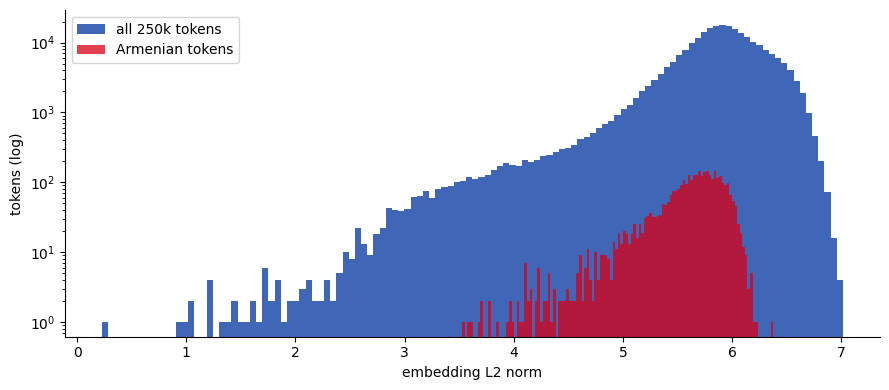

global lowest-norm tokens (any script):
  norm=0.225  id=      1  '<pad>'  corpus_count=0
  norm=0.912  id=  78124  'nee'  corpus_count=0
  norm=0.989  id= 249289  '߅'  corpus_count=0
  norm=1.040  id= 248875  'ᘢ'  corpus_count=0
  norm=1.043  id=  68253  '▁ment'  corpus_count=0
  norm=1.188  id= 247966  '籀'  corpus_count=0
  norm=1.193  id=  60794  'naa'  corpus_count=0
  norm=1.235  id= 136495  '▁ais'  corpus_count=0
  norm=1.238  id= 248467  'ໟ'  corpus_count=0
  norm=1.323  id=  90883  '▁ට'  corpus_count=0
  norm=1.359  id= 248817  '᷆'  corpus_count=0
  norm=1.436  id= 248418  '鉿'  corpus_count=0
  norm=1.463  id= 248955  '煋'  corpus_count=0
  norm=1.473  id=  97636  '\x85'  corpus_count=0
  norm=1.545  id= 249583  '\U000f081c'  corpus_count=0

ARMENIAN GLITCH CANDIDATES (never in corpus, lowest norm first):
  norm=3.605  id=  89824  խմբագրել
  norm=3.689  id= 229607  ▁Արտասանել
  norm=3.709  id= 248526  ֍
  norm=3.717  id= 236082  ▁Զրուցարան
  norm=3.771  id= 241990  ▁ԱՐՄԵՆՊՐԵՍ
  

In [15]:
if not SKIP_WEIGHTS:
    arm_ids_sorted = sorted(xlmr_arm)
    arm_norms = {i: float(norms[i]) for i in arm_ids_sorted}

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(norms.numpy(), bins=120, color=ARM_BLUE, alpha=0.75, label="all 250k tokens")
    ax.hist(list(arm_norms.values()), bins=120, color=ARM_RED, alpha=0.75,
            label="Armenian tokens")
    ax.set_yscale("log")
    ax.set_xlabel("embedding L2 norm"); ax.set_ylabel("tokens (log)")
    ax.legend(); ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout(); fig.savefig(OUT / "fig_norms.png", dpi=150)
    plt.show()

    # global bottom-30: the SolidGoldMagikarp zone of XLM-R (any script)
    bottom = norms.argsort()[:30].tolist()
    print("global lowest-norm tokens (any script):")
    for i in bottom[:15]:
        print(f"  norm={float(norms[i]):.3f}  id={i:>7d}  "
              f"{xlmr.internal_forms([i])[0]!r}  corpus_count={cnt.get(i, 0)}")

    # Armenian candidates: corpus-null, sorted by norm ascending
    cand = sorted(null_ids, key=lambda i: arm_norms[i])[:20]
    print("\nARMENIAN GLITCH CANDIDATES (never in corpus, lowest norm first):")
    for i in cand:
        print(f"  norm={arm_norms[i]:.3f}  id={i:>7d}  {xlmr.internal_forms([i])[0]}")

    import numpy as np
    edges = np.linspace(0, float(norms.max()), 61)
    hist_all = np.histogram(norms.numpy(), bins=edges)[0]
    hist_arm = np.histogram(np.array(list(arm_norms.values())), bins=edges)[0]

    glitch = {
        "norm_hist": {"bin_edges": edges.round(4).tolist(),
                      "all": hist_all.tolist(), "armenian": hist_arm.tolist()},
        "n_armenian_tokens": len(xlmr_arm),
        "n_corpus_null": len(null_ids),
        "corpus_chars": sum(len(a) for a in hy_articles),
        "norm_median_all": float(norms.median()),
        "norm_median_armenian": float(torch.tensor(list(arm_norms.values())).median()),
        "global_bottom30": [{"id": i, "internal": xlmr.internal_forms([i])[0],
                             "norm": round(float(norms[i]), 4),
                             "corpus_count": cnt.get(i, 0)} for i in bottom],
        "armenian_candidates": [{"id": i, "internal": xlmr.internal_forms([i])[0],
                                 "norm": round(arm_norms[i], 4)} for i in cand],
        "armenian_top_used": [{"id": i, "internal": xlmr.internal_forms([i])[0],
                               "count": seen[i],
                               "norm": round(arm_norms[i], 4)} for i in top_ids],
    }

### Clustering the Armenian embedding space

The original SolidGoldMagikarp tokens were *found* by k-means clustering token
embeddings: undertrained tokens huddle together near the embedding centroid,
because they all stayed close to the shared initialization while trained tokens
marched away from it. Same experiment on the Armenian slice: cluster the ~3.5k
Armenian token vectors, see where the corpus-null candidates land, and measure
every token's cosine distance to the global (all-250k) embedding centroid.
The embedding slice and all norms also get saved to `data/` as npz for further play.

In [16]:
if not SKIP_WEIGHTS:
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA

    with safe_open(st_path, framework="pt") as f:
        W_all = f.get_tensor(emb_key[0])
    global_mean = W_all.mean(0)
    E = W_all[arm_ids_sorted].numpy().astype(np.float32)
    del W_all  # free the 768 MB again before the MLM model loads below

    np.savez_compressed(DATA / "xlmr_armenian_embeddings.npz",
                        ids=np.array(arm_ids_sorted), emb=E)
    np.savez_compressed(DATA / "xlmr_all_norms.npz", norms=norms.numpy())
    print(f"saved embedding slice {E.shape} + all 250k norms to data/")

    En = E / np.linalg.norm(E, axis=1, keepdims=True)
    gm = (global_mean / global_mean.norm()).numpy()
    dist_centroid = 1 - En @ gm

    forms = xlmr.internal_forms(arm_ids_sorted)
    cand_set, top_set = set(cand), set(top_ids)
    is_cand = np.array([i in cand_set for i in arm_ids_sorted])
    is_top = np.array([i in top_set for i in arm_ids_sorted])
    cd_cand = float(dist_centroid[is_cand].mean())
    cd_rest = float(dist_centroid[~is_cand].mean())
    print(f"cosine distance to global centroid: candidates {cd_cand:.4f} "
          f"vs other Armenian tokens {cd_rest:.4f}")

saved embedding slice (3528, 768) + all 250k norms to data/
cosine distance to global centroid: candidates 0.6341 vs other Armenian tokens 0.6252


In [17]:
if not SKIP_WEIGHTS:
    K = 10
    km = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(En)
    lab = km.labels_
    clusters = []
    for c in range(K):
        rows = np.where(lab == c)[0]
        d = np.linalg.norm(En[rows] - km.cluster_centers_[c], axis=1)
        clusters.append({
            "cluster": int(c), "size": int(len(rows)),
            "mean_norm": round(float(np.mean(
                [arm_norms[arm_ids_sorted[r]] for r in rows])), 3),
            "median_count": int(np.median(
                [cnt.get(arm_ids_sorted[r], 0) for r in rows])),
            "n_candidates": int(is_cand[rows].sum()),
            "sample": [forms[r] for r in rows[np.argsort(d)[:6]]],
        })
    print("clusters sorted by mean embedding norm (glitch zone on top):")
    for cl in sorted(clusters, key=lambda x: x["mean_norm"]):
        print(f"  #{cl['cluster']}: size={cl['size']:>5}  norm={cl['mean_norm']:>6}  "
              f"median_count={cl['median_count']:>6}  candidates={cl['n_candidates']:>2}  "
              f"e.g. {'  '.join(cl['sample'][:4])}")

clusters sorted by mean embedding norm (glitch zone on top):
  #9: size=  161  norm= 5.109  median_count=   213  candidates= 2  e.g. Ելք  Հանրապետական  Վանաձոր  Կովկաս
  #3: size=  382  norm= 5.376  median_count=   412  candidates= 6  e.g. ▁Տարոն  ▁Երկրորդ  ▁Լավ  ▁Ես
  #5: size=  120  norm= 5.585  median_count=    29  candidates= 4  e.g. Ի  ԻԿ  ԱՐ  ԵԼ
  #7: size=  532  norm= 5.601  median_count=   256  candidates= 1  e.g. ▁վաղուց  ▁լուծել  ▁օգնել  ▁պահել
  #2: size=  346  norm=  5.61  median_count=  1034  candidates= 0  e.g. ▁տրամ  ▁եւ  ▁ստոր  ▁գոլ
  #0: size=  333  norm= 5.623  median_count=   974  candidates= 1  e.g. ության  աժամկետ  ախմբի  ների
  #6: size=  443  norm= 5.672  median_count=   271  candidates= 0  e.g. ▁հարթակ  ▁քննություն  ▁զեկույց  ▁ուղերձ
  #1: size=  256  norm= 5.686  median_count=   347  candidates= 0  e.g. ▁նկարահան  ▁մաքր  ▁ճնշ  ▁ներմուծ
  #4: size=  412  norm=   5.7  median_count=   237  candidates= 0  e.g. ▁կազմակերպության  ▁նախնական  ▁շարժման  ▁հանրապետության


C:\Users\hayk_\AppData\Local\Temp\ipykernel_32832\4009661862.py:16: UserWarning: Glyph 1421 (\N{RIGHT-FACING ARMENIAN ETERNITY SIGN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\hayk_\AppData\Local\Temp\ipykernel_32832\4009661862.py:17: UserWarning: Glyph 1421 (\N{RIGHT-FACING ARMENIAN ETERNITY SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT / "fig_embedding_map.png", dpi=150)


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1421 (\N{RIGHT-FACING ARMENIAN ETERNITY SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


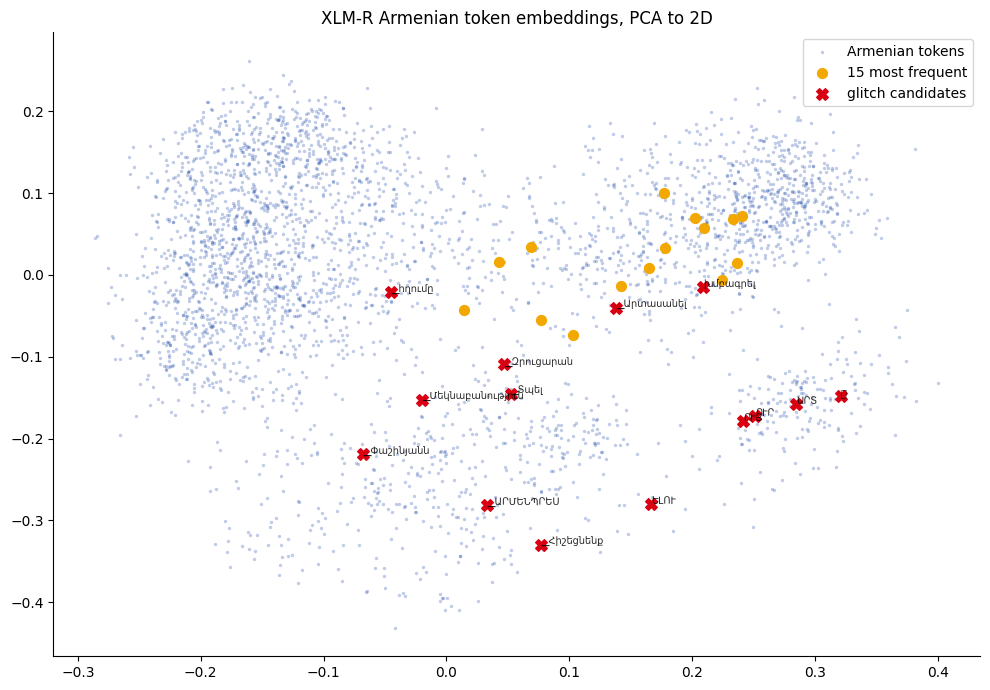

In [18]:
if not SKIP_WEIGHTS:
    xy = PCA(n_components=2, random_state=SEED).fit_transform(En)
    plain = ~(is_cand | is_top)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(xy[plain, 0], xy[plain, 1], s=6, c=ARM_BLUE, alpha=0.25, lw=0,
               label="Armenian tokens")
    ax.scatter(xy[is_top, 0], xy[is_top, 1], s=50, c=ARM_ORANGE,
               label="15 most frequent")
    ax.scatter(xy[is_cand, 0], xy[is_cand, 1], s=70, c=ARM_RED, marker="X",
               label="glitch candidates")
    for r in np.where(is_cand)[0]:
        ax.annotate(forms[r], (xy[r, 0], xy[r, 1]), fontsize=7, alpha=0.85)
    ax.legend()
    ax.set_title("XLM-R Armenian token embeddings, PCA to 2D")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(OUT / "fig_embedding_map.png", dpi=150)
    plt.show()

    glitch["embedding_clusters"] = {
        "k": K,
        "centroid_dist_candidates": round(cd_cand, 4),
        "centroid_dist_rest": round(cd_rest, 4),
        "clusters": clusters,
    }
    glitch["pca_map"] = {
        "x": np.round(xy[:, 0], 4).tolist(), "y": np.round(xy[:, 1], 4).tolist(),
        "token": forms,
        "norm": [round(arm_norms[i], 3) for i in arm_ids_sorted],
        "count": [int(cnt.get(i, 0)) for i in arm_ids_sorted],
        "cluster": lab.tolist(),
        "is_candidate": is_cand.astype(int).tolist(),
        "is_top": is_top.astype(int).tolist(),
    }
    del E, En, xy

### The probe: can the model even *say* these tokens?

MLM version of the "repeat after me" glitch test: show the model a token three
times, mask the fourth repetition, and ask what goes in the blank. A healthy
token gets copied with high probability; an undertrained one does not - the model
cannot see what it never learned to represent.

In [19]:
if not SKIP_WEIGHTS:
    from transformers import AutoModelForMaskedLM, AutoTokenizer

    hf_tok = xlmr.raw
    model = AutoModelForMaskedLM.from_pretrained("FacebookAI/xlm-roberta-base")
    model.eval()

    def repeat_probe(piece_id: int):
        """P(model fills the 4th slot with the same token it just saw 3 times)."""
        word = hf_tok.decode([piece_id]).strip()
        if not word:
            return None
        # trailing comma so the mask is not the final position - otherwise the
        # model mostly predicts </s> there and every probe drowns in that signal
        text = f"{word}, {word}, {word}, {hf_tok.mask_token},"
        enc = hf_tok(text, return_tensors="pt")
        # the probe only makes sense if the word round-trips to exactly [piece_id]
        reps = [i for i in enc.input_ids[0].tolist() if i == piece_id]
        if len(reps) != 3:
            return {"word": word, "note": "does not round-trip to a single token"}
        with torch.no_grad():
            logits = model(**enc).logits
        pos = (enc.input_ids[0] == hf_tok.mask_token_id).nonzero()[0, 0]
        probs = logits[0, pos].softmax(-1)
        rank = int((probs > probs[piece_id]).sum()) + 1
        return {"word": word, "p_copy": round(float(probs[piece_id]), 4),
                "rank": rank,
                "model_says": hf_tok.decode([int(probs.argmax())]).strip()}

    # NB the ligature: XLM-R's normalizer rewrites և -> եւ, so the vocab piece is
    # ▁Երեւան - the ligature spelling ▁Երևան is NOT in the vocab and maps to <unk>
    controls = [hf_tok.convert_tokens_to_ids(t) for t in ["▁Երեւան", "▁Հայաստան"]]
    probe_ids = [i for i in controls if i is not None and i != hf_tok.unk_token_id]
    probe_ids += [i for i in cand if xlmr.internal_forms([i])[0].startswith("▁")][:6]

    probes = []
    for i in probe_ids:
        r = repeat_probe(i)
        if r:
            r["id"] = i
            r["kind"] = "control" if i in controls else "candidate"
            probes.append(r)
            print(f"[{r['kind']:9s}] {r['word']:25s} "
                  f"p_copy={r.get('p_copy', '-'):>8}  rank={r.get('rank', '-'):>6}  "
                  f"model_says={r.get('model_says', r.get('note'))!r}")

    glitch["repeat_probe"] = probes
    save_json("glitch_candidates.json", glitch)
    del model, norms

[control  ] Երեւան                    p_copy=  0.0006  rank=   112  model_says=','
[control  ] Հայաստան                  p_copy=  0.0212  rank=     3  model_says=','


[candidate] Արտասանել                 p_copy=     0.0  rank=  9459  model_says=','


[candidate] Զրուցարան                 p_copy=   0.002  rank=    31  model_says='chat'
[candidate] ԱՐՄԵՆՊՐԵՍ                 p_copy=     0.0  rank=  6340  model_says='Romania'


[candidate] Հիշեցնենք                 p_copy=  0.0039  rank=    10  model_says=','
[candidate] Տպել                      p_copy=  0.0032  rank=    21  model_says='-'


[candidate] Մեկնաբանություն           p_copy=  0.0509  rank=     2  model_says=','
saved out\glitch_candidates.json (495,790 bytes)


## 7. Word gallery - famous words across all eight tokenizers

The everyday test: how many tokens is Երևան? շնորհակալություն? մարշուտկա?

In [20]:
GALLERY = ["Երևան", "Հայաստան", "բարև", "շնորհակալություն", "խաչքար",
           "Արարատ", "ջան", "Վերնիսաժ", "մարշուտկա", "և"]

gallery = {"words": GALLERY, "tokenizers": {}}
header = f"{'word':>18s} | " + " | ".join(f"{n:^9s}" for n in toks)
print(header); print("-" * len(header))
for w in GALLERY:
    counts = {}
    for name, t in toks.items():
        ids = t.encode(w)
        counts[name] = {"n": len(ids), "pieces": t.token_pieces(ids)}
    gallery["tokenizers"][w] = counts
    print(f"{w:>18s} | " + " | ".join(f"{counts[n]['n']:^9d}" for n in toks))
save_json("word_gallery.json", gallery)

              word | xlm-roberta |   mbert   |   gpt2    |  cl100k   |   o200k   |  llama3   |  gemma2   |  qwen2.5 
--------------------------------------------------------------------------------------------------------------------
             Երևան |     1     |     1     |    10     |    10     |     3     |     8     |     4     |     5    
          Հայաստան |     1     |     1     |    16     |    16     |     2     |    10     |     4     |     8    
              բարև |     2     |     3     |     8     |     8     |     3     |     7     |     3     |     4    
  շնորհակալություն |     2     |     8     |    32     |    32     |     4     |    28     |     7     |    16    
            խաչքար |     3     |     5     |    12     |    12     |     4     |     9     |     5     |     6    
            Արարատ |     2     |     4     |    12     |    12     |     4     |     9     |     3     |     6    
               ջան |     2     |     2     |     6     |     6     |     2  

## 8. Run metadata

In [21]:
import datetime
import datasets as _ds
import tiktoken as _tt
import transformers as _tf

meta = {
    "run_at": datetime.datetime.now().isoformat(timespec="seconds"),
    "seed": SEED,
    "max_chars_hy": MAX_CHARS_HY, "max_chars_en": MAX_CHARS_EN,
    "skip_weights": SKIP_WEIGHTS,
    "n_hy_articles": len(hy_articles), "n_en_articles": len(en_articles),
    "versions": {"transformers": _tf.__version__, "tiktoken": _tt.__version__,
                 "datasets": _ds.__version__, "python": sys.version.split()[0]},
    "tokenizers": {n: TOKENIZERS[n] for n in TOKENIZERS},
}
save_json("meta.json", meta)
print("done - all results under out/, report via build_report.py")

saved out\meta.json (1,456 bytes)
done - all results under out/, report via build_report.py
